# DBLP dataset analysis

## 0. Introduction

This project is focused on analizing the biggest available dataset about Computer Science Papers. My main goal is to extract the most interesting information and use best fit of AI/ML models for this problem.

 - 0. Introduction
 - 1. Dataset analysis
   - a. Parsing data
- 2. Data Science  
  - a. The difference in Computer Science research topics per decade - Clustering
  - b. Smart topic recommendation using emmbeding

## 1. Dataset analysis

One of most crucial steps in Data Science is to fully understand the concept. That's why my first step is going to be understanding dataset structure.

For xml file read I've decided to use lxml library, because it's more time efficient than a standard Python library for *.xml.

In [114]:
# Frameworks
from lxml import etree
import numpy as np
import pandas as pd
from src.data_analysis_helper import DataAnalysisHelper
from sentence_transformers import SentenceTransformer 
from umap import UMAP
import matplotlib.pyplot as plt 
from hdbscan import HDBSCAN 
#from bertopic import BERTopic 

In [115]:
lis_range = list(range(2004, 2024))
new_lis_range = []
for i, idx in enumerate(lis_range):
    new_lis_range.append(str(lis_range[i]))

new_lis_range

['2004',
 '2005',
 '2006',
 '2007',
 '2008',
 '2009',
 '2010',
 '2011',
 '2012',
 '2013',
 '2014',
 '2015',
 '2016',
 '2017',
 '2018',
 '2019',
 '2020',
 '2021',
 '2022',
 '2023']

### Based on the dblp.dtd, the available XML tags are as follows:


main:
- `article` - artykuł naukowy opublikowany w czasopiśmie
- `inproceedings` - artykuł w materiałach konferencyjnych
- `proceedings` - całe materiały konferencyjne (zbiór artykułów)
- `book` - książka (monografia)
- `incollection` - rozdział w książce lub pracy zbiorowej
- `phdthesis` - rozprawa doktorska
- `mastersthesis` - praca magisterska
- `www` - zasób internetowy (np. strona WWW)
- `person` - informacja o osobie (np. autorze)
- `data` - zbiór danych lub dataset

Parameter Entity:
- `author` - autor publikacji
- `editor` - redaktor (np. książki lub materiałów konferencyjnych)
- `title` - tytuł publikacji
- `booktitle` - tytuł książki lub konferencji, w której opublikowano pracę
- `pages` - zakres stron
- `year` - rok publikacji
- `address` - miejsce wydania (np. miasto)
- `journal` - nazwa czasopisma
- `volume` - numer tomu
- `number` - numer wydania w ramach tomu
- `month` - miesiąc publikacji
- `url` - link do publikacji
- `ee` - link do wersji elektronicznej (electronic edition)
- `cdrom` - lokalizacja wersji na nośniku CD-ROM
- `cite` - odwołanie do innej publikacji
- `publisher` - wydawnictwo
- `note` - dodatkowe informacje
- `crossref` - odwołanie do innego wpisu (np. konferencji)
- `isbn` - numer ISBN książki
- `series` - seria wydawnicza
- `school` - uczelnia (dla prac dyplomowych)
- `chapter` - numer rozdziału
- `publnr` - numer publikacji (np. raportu technicznego)
- `stream` - strumień lub kategoria publikacji
- `rel` - relacja z innymi wpisami

### Parsing data from *.xml - gathering data to datasets from .xml to pandas DataFrame

My first idea was to pick 100 papaers from every month from every year. By this method, our data would be heterogeneous. However, results in tests showed that there're not enough labaled 'month' tags for later unsupervised clustering implementation. Because of that, I needed to pick the total value, without breakdown by months.

In [116]:
all_top_tags = {"article", "inproceedings", "proceedings", "book", 
                        "incollection", "phdthesis", "mastersthesis", "www", "person", "data"}


sub_tags = {"author", "editor", "title", "booktitle", "pages", "year", "address",
          "journal", "volume", "number", "month", "url", "ee", "cdrom", "cite",
            "publisher", "note", "crossref", "isbn", "series", "school", "chapter",
              "publnr", "stream", "rel"}

month_range = ['January', 'February', 'March', 'April', 'May', 'June',
                       'July', 'August', 'September', 'October', 'November', 'December']
year_range = ["2004", "2014", "2024"]



In [117]:

xml_path = r"C:\Users\wikto\OneDrive\Dokumenty\all-datasets\dblp-dataset\dblp.xml"


helper_class = DataAnalysisHelper(xml_path, all_top_tags)
publications = year_title_publications = helper_class.parse_publications(year_range)


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\wikto\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\wikto\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\wikto\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


Limit reached for 2024....
Limit reached for 2014....
Limit reached for 2004....
Limit reached for every year. Ending....


Saving to Pandas Dataframe

In [118]:
flatted_data = []

for year, records in publications.items():
    for record in records:
        flatted_data.append({
            "Year": year,
            "Type": record["type"],      
            "Author": record["author"],  
            "Title": record["title"],    
            "Journal": record["journal"],
            "Booktitle": record["booktitle"],
            "Address": record["address"],
            "Month": record["month"]
        })


df = pd.DataFrame(flatted_data)

In [119]:
df

,Year,Type,Author,Title,Journal,Booktitle,Address,Month
0,2004,book,Jeremy J. Ramsden,Bioinformatics: An Introduction,None,None,None,None
1,2004,book,None,Artificial Intelligence Methods And Tools For ...,None,None,None,None
2,2004,book,None,The Rise of Modern Logic: From Leibniz to Frege,None,None,None,None
3,2004,book,None,"Greek, Indian and Arabic Logic",None,None,None,None
4,2004,book,Klaus Schneider 0001,Verification of Reactive Systems - Formal Meth...,None,None,None,None
...,...,...,...,...,...,...,...,...
3595,2024,inproceedings,"Dongjin Kang, Sunghwan Kim 0005, Taeyoon Kwon,...",Can Large Language Models be Good Emotional Su...,None,ACL (1),None,None
3596,2024,inproceedings,"Xinran Chen, Xuanang Chen, Ben He 0001, Tengfe...","Analyze, Generate and Refine: Query Expansion ...",None,ACL (Findings),None,None
3597,2024,inproceedings,"Lin Long, Rui Wang 0076, Ruixuan Xiao, Junbo Z...","On LLMs-Driven Synthetic Data Generation, Cura...",None,ACL (Findings),None,None
3598,2024,inproceedings,"Zihao Xu, Yi Liu 0069, Gelei Deng, Yuekang Li,...",A Comprehensive Study of Jailbreak Attack vers...,None,ACL (Findings),None,None


## 2. Data Science

### The difference in Computer Science research topics per decade by using unsupervised methods
In this section, I will analyze the evolution of research topics across three decades. Since the dataset is unlabeled, classic supervised learning is not an option unless I were to label the samples manually. For this, I'm going to use NLP and clustering techniques.

A. Text Clustering approach

1. `Preprocessing` - of course, computer is a binary machine that doesn't understand a concept of words as letters. That's why it's important to change words to vector float representation. For this, data needs to be clean - with no upperletters, stopwords or other type of noise.
2. `Embbeding` - as I've said, we need numeric representetion of words. Embedding is a method that changes words to numbers, and represents them in high dimension. For example, words like "cat" and "dog" are going to be closer to each other than "car".
3. `Reducing the dimensionality` - we can not see in more than third dimension, that's why in unsupervised learning we use methods like **PCA, UMAP or t-SNE** to reduce the dimension. This is particularly important for visualizing clusters of semantically similar words.
4. `Clustering` -
5. `Plotting` - 

In [120]:
# Preprocessing data for NLP ready usage

prepared_titles = helper_class.preprocess_for_nlp(df, "Title")
prepared_titles


0                          [bioinformatics, introduction]
1       [artificial, intelligence, methods, tools, sys...
2                   [rise, modern, logic, leibniz, frege]
3                          [greek, indian, arabic, logic]
4       [verification, reactive, systems, formal, meth...
                              ...                        
3595    [large, language, models, good, emotional, sup...
3596    [analyze, generate, refine, query, expansion, ...
3597    [llmsdriven, synthetic, data, generation, cura...
3598    [comprehensive, study, jailbreak, attack, vers...
3599    [perturbed, examples, reveal, invariances, sha...
Name: Title, Length: 3600, dtype: object

In [121]:
# Embedding

# ! ! For now I'm using gte model - which has it's own tokenize methold build within. ! !
# ! ! That's why I'm using preprocessed titles. ! !
only_titles = df['Title']
only_titles = only_titles.str.lower().tolist()


'''Code below is to prevent downloading'''
#embedding_model = SentenceTransformer("thenlper/gte-small") 
#embeddings = embedding_model.encode(only_titles, show_progress_bar=True)

# Save embeddings
#np.save('data/dblp_embeddings.npy', embeddings)

# Load embeddings - for now, easy numpy (bc I want plot some correlations)
# For RAG and smart searchers it's told to use vector databases like ChromaDB
embeddings = np.load(r"C:\Users\wikto\OneDrive\Dokumenty\AA_projects\DBLP-dataset-analysis\data\dblp_embeddings.npy")



In [122]:
# Reducing dimensionality for visualization and clustering
# I’ll use UMAP as it tends to handle nonlinear relationships better

umap_reduce = UMAP(n_components=2, min_dist=0.0, metric='cosine', random_state=123)
reduced_embeddings = umap_reduce.fit_transform(embeddings)

# Important! UMAP and every dimensionality reducing algorithm can cause information loss.

c:\Users\wikto\anaconda3\envs\dblp-analysis\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [175]:
# Clustering using density-based algorithms
# those algorithms calculate the number of clusters freely and do not force all points into a cluster.
# We’ll use HDBSCAN for our case.


hdbscan_model = HDBSCAN(min_cluster_size=70, metric="euclidean", cluster_selection_method="eom").fit(reduced_embeddings)
clusters = hdbscan_model.labels_

clusters

# Checks if clusters are similar
#cluster = -1

for index in np.where(clusters==cluster)[0][:5]:
    print(only_titles[index]+ "... \n")



the rise of modern logic: from leibniz to frege... 

logic, epistemology, and the unity of science... 

software-produkt-management - nachhaltiger erfolgsfaktor bei herstellern und anwendern.... 

high performance discovery in time series - techniques and case studies... 

large eddy simulation of turbulent incompressible flows - analytical and numerical results for a class of les models.... 



(np.float64(-0.43790644221007824),
 np.float64(10.951829737052321),
 np.float64(-0.7707791343331337),
 np.float64(6.042979808151722))

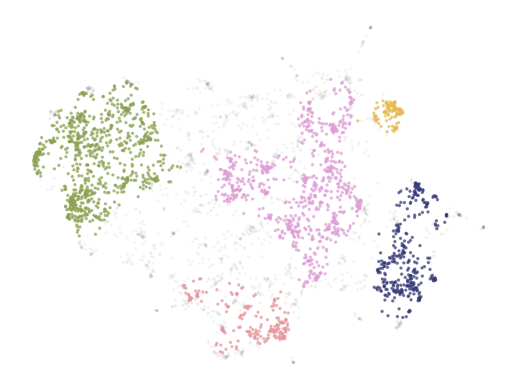

In [177]:
# Plotting data

df_clusters = pd.DataFrame(reduced_embeddings, columns=["x1", "x2"])
df_clusters["title"] = only_titles
df_clusters["cluster"] = [str(c) for c in clusters] 

# Outliers and non outliers
to_plot = df_clusters.loc[df_clusters.cluster != "-1", :] 
outliers = df_clusters.loc[df_clusters.cluster == "-1", :]

plt.scatter(outliers.x1, outliers.x2, alpha=0.05, s=2, c="grey") 
plt.scatter(to_plot.x1, to_plot.x2, c=to_plot.cluster.astype(int), alpha=0.6, s=2, cmap="tab20b" ) 
plt.axis("off")

In [178]:
# Statistics for years
df_year_titles = df[['Year', 'Title']]
df_with_clusters = df_year_titles.join(df_clusters)

df_with_clusters
df_without_noise = df_with_clusters[df_with_clusters['cluster'] != "-1"]
df_without_noise['cluster'] = df_without_noise['cluster'].astype(int)

df_without_noise

,Year,Title,x1,x2,title,cluster
0,2004,Bioinformatics: An Introduction,5.421123,2.668281,bioinformatics: an introduction,4
1,2004,Artificial Intelligence Methods And Tools For ...,5.515280,2.757991,artificial intelligence methods and tools for ...,4
3,2004,"Greek, Indian and Arabic Logic",6.275220,2.921612,"greek, indian and arabic logic",4
4,2004,Verification of Reactive Systems - Formal Meth...,7.045288,2.933893,verification of reactive systems - formal meth...,4
5,2004,The Parametric Lambda Calculus - A Metamodel f...,6.734993,2.877929,the parametric lambda calculus - a metamodel f...,4
...,...,...,...,...,...,...
3594,2024,SALAD-Bench: A Hierarchical and Comprehensive ...,1.144283,2.217133,salad-bench: a hierarchical and comprehensive ...,1
3596,2024,"Analyze, Generate and Refine: Query Expansion ...",2.616455,2.987272,"analyze, generate and refine: query expansion ...",1
3597,2024,"On LLMs-Driven Synthetic Data Generation, Cura...",2.664648,2.911512,"on llms-driven synthetic data generation, cura...",1
3598,2024,A Comprehensive Study of Jailbreak Attack vers...,1.124645,2.136734,a comprehensive study of jailbreak attack vers...,1


In [179]:
unique, counts = np.unique(clusters, return_counts=True)
cluster_stats = dict(zip(unique, counts))

print("Claster statistics:")
print(cluster_stats)

# Clusters with class "-1" are classified as noise

Claster statistics:
{np.int64(-1): np.int64(1420), np.int64(0): np.int64(331), np.int64(1): np.int64(826), np.int64(2): np.int64(110), np.int64(3): np.int64(188), np.int64(4): np.int64(725)}


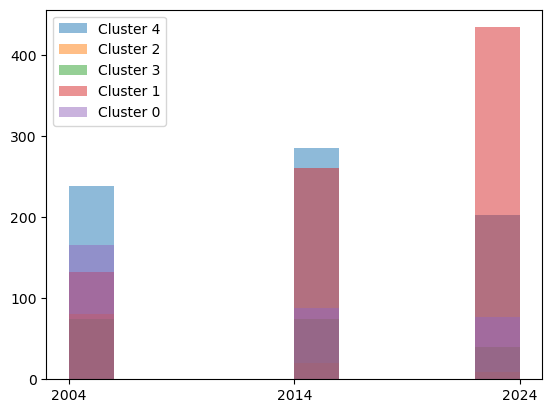

In [180]:
for cluster_id in df_without_noise["cluster"].unique():
    subset = df_without_noise[df_without_noise["cluster"] == cluster_id]
    plt.hist(subset["Year"], alpha=0.5, label=f"Cluster {cluster_id}")

plt.legend()
plt.show()

In [185]:
print(f'Example titles for cluster 1:\n {df_without_noise['title'][df_without_noise['cluster'] == 1].iloc[:3]}')


Example titles for cluster 1:
 20    argumentation machines, new frontiers in argum...
28    rough-neural computing: techniques for computi...
69                               cognitive linguistics.
Name: title, dtype: str


In [182]:

print(f'Example titles for cluster 2:\n {df_without_noise['title'][df_without_noise['cluster'] == 2].iloc[:3]}')


Example titles for cluster 2:
 10    modellierung mit uml - sprache, konzepte und m...
11    mobile datenbanksysteme - architektur, impleme...
12                     modellbildung in der informatik.
Name: title, dtype: str


In [184]:

print(f'Example titles for cluster 4:\n {df_without_noise['title'][df_without_noise['cluster'] == 4].iloc[:3]}')

Example titles for cluster 4:
 0                      bioinformatics: an introduction
1    artificial intelligence methods and tools for ...
3                       greek, indian and arabic logic
Name: title, dtype: str


**Conclusion about text clustering:** From those charts we can see how AI and LLM's got popular in 2024 (class 1)

B. Topic Modeling approach

Topic modeling approach is more probabilistic. For example, in this approach we can classify some papper as 80% about network protocols, and other 20% about Machine Learning (for example, there was used ML algorithm for networks). It gives us more freedom - and more immportly, we can see some trend in passing years.